In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/customer_support_tickets_clean.csv")

df.head()

,subject,body,answer,type,queue,priority,ticket_text,clean_text
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,"Account Disruption Dear Customer Support Team,...",account disruption dear customer support team ...
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,Query About Smart Home System Integration Feat...,query about smart home system integration feat...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,Inquiry Regarding Invoice Details Dear Custome...,inquiry regarding invoice details dear custome...
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,Question About Marketing Agency Software Compa...,question about marketing agency software compa...
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,"Feature Query Dear Customer Support,\n\nI hope...",feature query dear customer support i hope thi...


In [4]:
print(df.shape)

(16335, 8)


In [5]:
print(df["priority"].value_counts())

print(df["priority"].value_counts(normalize=True) * 100)

priority
medium    6616
high      6345
low       3374
Name: count, dtype: int64
priority
medium    40.501990
high      38.842975
low       20.655035
Name: proportion, dtype: float64


In [6]:
X = df["clean_text"]
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining Priority Distribution:")
print(y_train.value_counts())

print("\nTesting Priority Distribution:")
print(y_test.value_counts())

Training samples: 13068
Testing samples: 3267

Training Priority Distribution:
priority
medium    5293
high      5076
low       2699
Name: count, dtype: int64

Testing Priority Distribution:
priority
medium    1323
high      1269
low        675
Name: count, dtype: int64


In [7]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(13068, 47854)
(3267, 47854)


In [8]:
priority_model = LinearSVC(
    C=5,
    random_state=42
)

priority_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [9]:
y_pred = priority_model.predict(X_test_tfidf)

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.7486991123354759
              precision    recall  f1-score   support

        high       0.76      0.80      0.78      1269
         low       0.73      0.64      0.68       675
      medium       0.74      0.75      0.75      1323

    accuracy                           0.75      3267
   macro avg       0.75      0.73      0.74      3267
weighted avg       0.75      0.75      0.75      3267



In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 5, 10, 20]
}

grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_search.best_params_)

MemoryError: Unable to allocate 2.38 MiB for an array with shape (624383,) and data type int32

In [ ]:
best_priority_model = grid_search.best_estimator_

y_pred = best_priority_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Optimized Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Optimized Accuracy: 0.7486991123354759
              precision    recall  f1-score   support

        high       0.76      0.80      0.78      1269
         low       0.73      0.64      0.68       675
      medium       0.74      0.75      0.75      1323

    accuracy                           0.75      3267
   macro avg       0.75      0.73      0.74      3267
weighted avg       0.75      0.75      0.75      3267



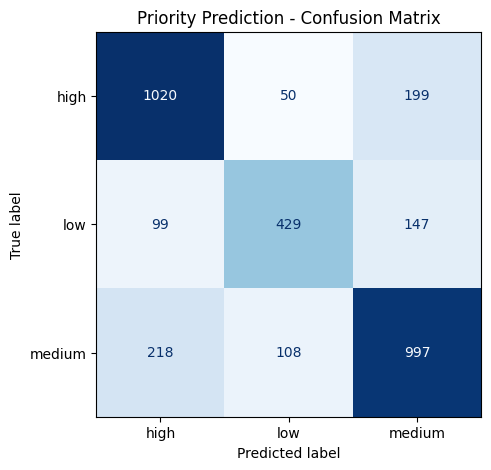

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_priority_model.classes_
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Priority Prediction - Confusion Matrix")
plt.show()

In [12]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(priority_model, "../models/priority_model.pkl")
joblib.dump(vectorizer, "../models/priority_vectorizer.pkl")

print("✅ Priority model saved successfully!")

✅ Priority model saved successfully!
